In [1]:
import pandas as pd
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import matplotlib.collections as mc


def strip_columns(df_raw) -> pd.DataFrame:
  df = df_raw.copy()
  stripped_columns = [col.strip() for col in df.columns]
  df.columns = stripped_columns
  return df

def mark_end_of_file(df_raw) -> pd.DataFrame:
  df = df_raw.copy()
  mask_end_of_data = df["Date"] == "END OF DATA"
  idx_eod_of_data = df[mask_end_of_data].index[0]
  df = df.iloc[:idx_eod_of_data-1, :]
  return df

# Month-Year
def process_date_month_year(val):
  if val is not None and isinstance(val, str) and "-" in val:
    if not pd.isna(pd.to_numeric(val, errors='coerce')):
      return None

    # if two occurrences of "-", return None
    if val.count("-") > 1:
      return None

    try:
      month_code, year_short = val.split("-")
      if len(month_code) == 3 and len(year_short) == 2:
        if int(year_short) <= 26:
          year = 2000 + int(year_short)
        else:
          year = 1900 + int(year_short)

        # convert 3-letter monthcode into month
        month = dt.datetime.strptime(month_code, "%b").month
        return dt.datetime(year, month, 1)
    except Exception as e:
      print(f"process_date_month_year: original value {val}", e)
  return None

def process_date_six_digit(val):
  if val is not None and isinstance(val, str) and len(val) == 6 and "-" not in val and "/" not in val and "°" not in val:
    try:
      year = int(val[:4])
      month = int(val[4:])
      return dt.datetime(year, month, 1)
    except Exception as e:
      print(f"process_date_six_digit: original value {val}", e)
  return None

def try_parse_datetime(val, max_year: int = 2026) -> np.datetime64:
  dt_obj = pd.to_datetime(val, errors="coerce")
  if pd.isna(dt_obj):
    return None
  if dt_obj.year > max_year and dt_obj.year < 2100:
    return dt_obj.replace(year=dt_obj.year - 100).to_datetime64()
  return dt_obj.to_datetime64()

In [2]:
df_input = pd.read_csv("global_temp_dirty_v2.csv")
df_input = strip_columns(df_input)
df_input = mark_end_of_file(df_input)

In [3]:
# Date Cleanup, Date Column
count_swap = 0
count_date_six_digit = 0
count_date_month_year = 0
count_date_other = 0

df_raw = df_input.copy()

for idx, row in df_raw.iterrows():
  date_val = row["Date"]
  temperature_val = row["Temperature_Anomaly"]

  date_val_processed = try_parse_datetime(date_val)
  if not pd.isna(date_val_processed):
    df_raw.loc[idx, "Date Cleaned"] = date_val_processed
    count_date_other += 1

  date_val_processed = process_date_month_year(date_val)
  if not pd.isna(date_val_processed):
    df_raw.loc[idx, "Date Cleaned"] = date_val_processed
    count_date_month_year += 1

  date_val_processed = process_date_six_digit(date_val)
  if not pd.isna(date_val_processed):
    df_raw.loc[idx, "Date Cleaned"] = date_val_processed
    count_date_six_digit += 1


  temperature_val_processed = try_parse_datetime(temperature_val)
  if not pd.isna(temperature_val_processed):
    df_raw.loc[idx, "Date Cleaned"] = temperature_val_processed
    df_raw.loc[idx, "Temperature_Anomaly"] = date_val
    count_date_other += 1
    count_swap += 1

  temperature_val_processed = process_date_month_year(temperature_val)
  if not pd.isna(temperature_val_processed):
    df_raw.loc[idx, "Date Cleaned"] = temperature_val_processed
    df_raw.loc[idx, "Temperature_Anomaly"] = date_val
    count_date_month_year += 1
    count_swap += 1

  temperature_val_processed = process_date_six_digit(temperature_val)
  if not pd.isna(temperature_val_processed):
    df_raw.loc[idx, "Date Cleaned"] = temperature_val_processed
    df_raw.loc[idx, "Temperature_Anomaly"] = date_val
    count_date_six_digit += 1
    count_swap += 1



In [4]:
# Value Cleanup
SENSOR_MALFUNCTION_CODES = [500, -500, 999, -999, "500", "-500", "999", "-999"]

def check_malfunction_code(val):
  if val in SENSOR_MALFUNCTION_CODES:
    return None
  elif isinstance(val, str) and val.strip() in SENSOR_MALFUNCTION_CODES:
    return None
  return val


# Inconsistent numeric formatting, including comma decimal separators ("-0,199") and a unit suffix (0.253°C).
def check_numeric_formatting(val):

  if isinstance(val, str) and "," in val:
    return float(val.replace(",", "."))
  if isinstance(val, str) and "°" in val:
    return float(val.replace("°C", "").replace("°F", ""))
  return val

# Missing-value tokens: blank, ., --, NaN, null, NA, N/A, #N/A, n/a, and missing
MISSINV_VALUE_TOKEN_LIST = ["", ".", "--", "NaN", "null", "NA", "N/A", "#N/A", "n/a", "missing"]
def check_missing_value_tokens(val):
  if isinstance(val, str):
    val = val.strip()
  if val in MISSINV_VALUE_TOKEN_LIST:
    return None
  return val

In [5]:
df_raw[df_raw["Date Cleaned"].isna()]

,Date,Temperature_Anomaly,Source/Notes,Date Cleaned


In [6]:
#count_malfunction_code = 0
count_numeric_formatting = 0
count_missing_str = 0

df_clean = df_raw.copy()
df_clean["Temperature_Anomaly Cleaned"] = "<PLACEHOLDER>"


for idx, row in df_clean.iterrows():
  temperature_val = row["Temperature_Anomaly"]

  temperature_val_processed = check_numeric_formatting(temperature_val)
  if not pd.isna(temperature_val_processed):
    df_clean.loc[idx, "Temperature_Anomaly Cleaned"] = temperature_val_processed
    count_numeric_formatting += 1

  temperature_val_processed = check_missing_value_tokens(temperature_val)
  if pd.isna(temperature_val_processed):
    df_clean.loc[idx, "Temperature_Anomaly Cleaned"] = None
    count_missing_str += 1


  #temperature_val_processed = check_malfunction_code(temperature_val)
  #if pd.isna(temperature_val_processed):
  #  df_clean.loc[idx, "Temperature_Anomaly Cleaned"] = None
  #  count_malfunction_code += 1

df_clean["Temperature_Anomaly Cleaned"] = df_clean["Temperature_Anomaly Cleaned"].astype(float)

In [7]:
df_clean[df_clean["Temperature_Anomaly Cleaned"] == "<PLACEHOLDER>"]

,Date,Temperature_Anomaly,Source/Notes,Date Cleaned,Temperature_Anomaly Cleaned


In [8]:
# Sort

In [9]:
df_clean = df_clean.sort_values("Date Cleaned")
total_clean_count = df_clean.shape[0]
df_clean = df_clean.drop_duplicates("Date Cleaned")
count_duplicate_date = total_clean_count - df_clean.shape[0]

In [10]:
df_clean = df_clean[["Date Cleaned", "Temperature_Anomaly Cleaned"]]
df_clean.columns = ["Date", "Temperature_Anomaly"]
df_clean.set_index("Date", inplace=True)

<Axes: xlabel='Date'>

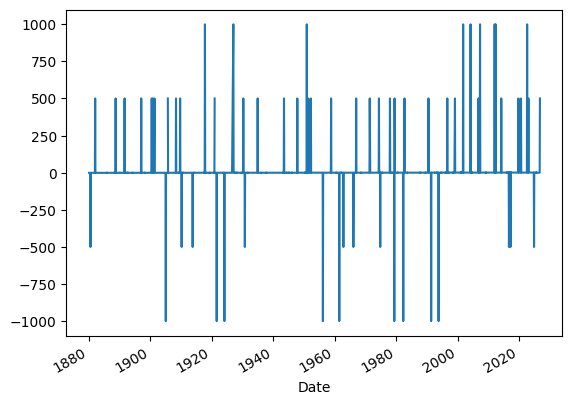

In [11]:
df_clean["Temperature_Anomaly"].plot()

In [12]:
# IQR Method
def outlier_process_iqr(df_raw):
  df = df_raw.copy()

  Q1 = df.quantile(0.25)
  Q3 = df.quantile(0.75)
  IQR = Q3 - Q1
  lo = Q1 - 1.5 * IQR
  hi = Q3 + 1.5 * IQR
  greater_than_q1 = df > lo
  smaller_than_q3 = df < hi

  count_removed = df[~greater_than_q1].dropna().shape[0] + df[~smaller_than_q3].dropna().shape[0]
  df[~greater_than_q1] = None
  df[~smaller_than_q3] = None
  return df, Q1, Q3, lo, hi, IQR, count_removed

In [13]:
df_processed, q1, q3, fence_lo, fence_hi, iqr_range, count_iqr_removed = outlier_process_iqr(df_clean)

In [14]:
count_iqr_removed

63

<Axes: xlabel='Date'>

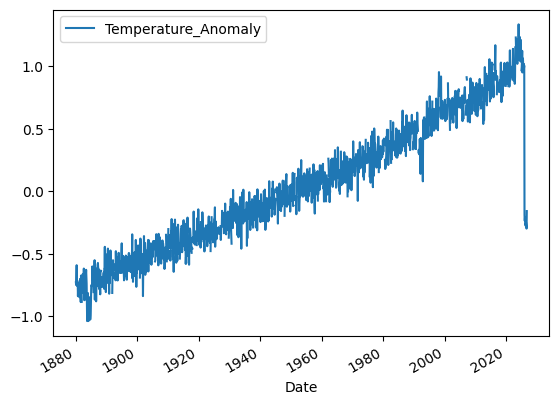

In [15]:
df_processed.plot()

In [16]:
# Missing Value Imputation
df_processed_full = df_processed.reindex(pd.date_range("1880-01-01", "2025-12-01", freq="MS"))

count_imputed = df_processed_full.isna().sum().iloc[0]
df_processed_full = df_processed_full.interpolate("linear", limit_direction="both")

In [17]:
count_imputed

np.int64(198)

In [18]:
mu_20 = df_processed_full["1901":"2000"].mean().iloc[0]
df_processed_full["d"] = df_processed_full["Temperature_Anomaly"] - mu_20


In [19]:
mu = df_processed_full.mean().iloc[0]
sigma = df_processed_full.std().iloc[0]
df_processed_full["z"] = (df_processed_full["Temperature_Anomaly"] - mu) / sigma

In [20]:
df_processed_full

,Temperature_Anomaly,d,z
1880-01-01,-0.7300,-0.729467,-1.491634
1880-02-01,-0.7520,-0.751467,-1.533925
1880-03-01,-0.6700,-0.669467,-1.376294
1880-04-01,-0.5930,-0.592467,-1.228275
1880-05-01,-0.7390,-0.738467,-1.508934
...,...,...,...
2025-08-01,0.9990,0.999533,1.832067
2025-09-01,1.0075,1.008033,1.848407
2025-10-01,1.0160,1.016533,1.864747
2025-11-01,0.9850,0.985533,1.805155


In [21]:
# Annual summary
from numpy import average
# yearly mean, yearly z-score
res_list = []
for year in range(1880, 2026):
  df_sub = df_processed_full[df_processed_full.index.year == year]
  mean_year = df_sub.mean().iloc[0]
  std_year = df_sub.std().iloc[0]
  z_score_year = ((df_sub - mean_year) / std_year).mean().iloc[0]
  res = {
      "year": year,
      "mean": mean_year,
      "std": std_year,
      "z_score": z_score_year
  }
  res_list.append(res)

df_res = pd.DataFrame(res_list)

In [22]:
df_res

,year,mean,std,z_score
0,1880,-0.747500,0.069850,9.251859e-16
1,1881,-0.792125,0.066920,-4.070818e-16
2,1882,-0.757875,0.074096,-4.996004e-16
3,1883,-0.820500,0.135178,9.084169e-16
4,1884,-0.917542,0.068479,-1.202742e-15
...,...,...,...,...
141,2021,0.940042,0.073695,1.628327e-15
142,2022,0.960458,0.076398,-1.249001e-15
143,2023,1.153208,0.062051,-8.789266e-16
144,2024,1.167708,0.083913,-7.401487e-17


In [23]:
df_res.sort_values("mean", ascending=False).head(5)

,year,mean,std,z_score
144,2024,1.167708,0.083913,-7.401487e-17
143,2023,1.153208,0.062051,-8.789266e-16
145,2025,1.012625,0.045212,2.442491e-15
136,2016,0.981542,0.078477,-1.295260e-15
142,2022,0.960458,0.076398,-1.249001e-15


In [24]:
# To color the line by value, use matplotlib.collections.LineCollection
# Position and color both encode the anomaly, which is what makes the chart dual-encoded.
# Mark | A line: x = time, y = temperature anomaly (°C).
# Channel | Color encodes d using a diverging palette centered at 0 (the 20th-century mean): blue = below average, red = above average. Use a centered normalization, e.g., TwoSlopeNorm(vcenter=0) or symmetric limits, with a colormap such as RdBu_r.
# Required labeling | Axis labels with units, a colorbar with a label, a horizontal reference line at the baseline, and a title or caption.
# Export | Vector PDF, or PNG at ≥ 300 dpi, sized for one IEEE column (3.5 in wide) or both columns (7.16 in).


# Prepare data for LineCollection
x = df_processed_full.index.map(mdates.date2num)
y = df_processed_full['Temperature_Anomaly'].values
d_values = df_processed_full['d'].values

# Create segments from x and y
points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
cmap = plt.get_cmap('RdBu_r')
norm = mcolors.TwoSlopeNorm(vmin=d_values.min(), vcenter=mu_20, vmax=d_values.max()) # Center at 0 (20th-century mean for 'd')


In [25]:
df_processed_full

,Temperature_Anomaly,d,z
1880-01-01,-0.7300,-0.729467,-1.491634
1880-02-01,-0.7520,-0.751467,-1.533925
1880-03-01,-0.6700,-0.669467,-1.376294
1880-04-01,-0.5930,-0.592467,-1.228275
1880-05-01,-0.7390,-0.738467,-1.508934
...,...,...,...
2025-08-01,0.9990,0.999533,1.832067
2025-09-01,1.0075,1.008033,1.848407
2025-10-01,1.0160,1.016533,1.864747
2025-11-01,0.9850,0.985533,1.805155


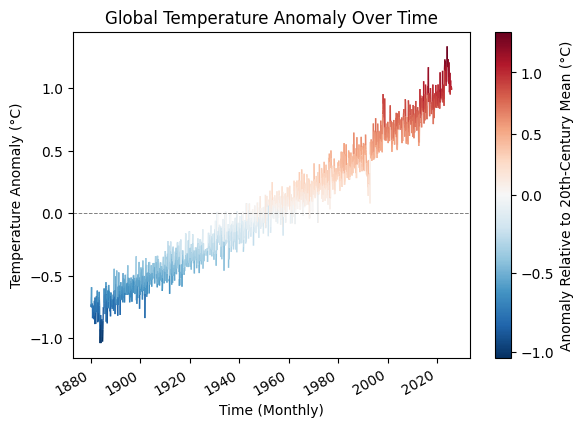

In [26]:

line_collection = mc.LineCollection(segments, cmap=cmap, norm=norm)
line_collection.set_array(d_values)
line_collection.set_linewidth(1)

fig, ax = plt.subplots()
ax.add_collection(line_collection)
ax.axhline(y=mu_20, color='gray', linestyle='--', linewidth=0.7, label='20th Century Mean (1901-2000)')

ax.set_xlabel('Time (Monthly)')
ax.set_ylabel('Temperature Anomaly (°C)')
ax.set_title('Global Temperature Anomaly Over Time')

# Set limits based on data range
ax.autoscale_view()


# X axis
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(20))
fig.autofmt_xdate()
#colorbar
cbar = fig.colorbar(line_collection, ax=ax, label='Anomaly Relative to 20th-Century Mean (°C)')
fig.savefig("temperature_anomaly_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [27]:
# Prepare things for report
# Data Cleaning Summary
data_cleaning_summary = {
    "Total": df_input.shape[0],
    "Column Swap": count_swap,
    "Six Digit Date": count_date_six_digit,
    "Month-Year Date": count_date_month_year,
    "General Date": count_date_other,
    "Numeric Formatting": count_numeric_formatting,
    "Missing Temperature": count_missing_str,
    "Duplicated Dates": count_duplicate_date,
    "IQR Removed": count_iqr_removed,
    "IQR Q1": q1.iloc[0],
    "IQR Q3": q3.iloc[0],
    "IQR Fence Lo": fence_lo.iloc[0],
    "IQR Fence Hi": fence_hi.iloc[0],
    "IQR Range": iqr_range.iloc[0],
    "Months Imputed": count_imputed,
}

df_data_cleaning_summary = pd.DataFrame(data_cleaning_summary, index=[0]).T
df_data_cleaning_summary.columns = ["Data Cleaning Summary"]
df_data_cleaning_summary

,Data Cleaning Summary
Total,1707.0000
Column Swap,40.0000
Six Digit Date,39.0000
Month-Year Date,589.0000
General Date,1492.0000
Numeric Formatting,1672.0000
Missing Temperature,63.0000
Duplicated Dates,20.0000
IQR Removed,63.0000
IQR Q1,-0.3850


In [28]:
print("20th centurty Mean:", mu_20)
print("All Mean:", mu)
print("All Std:", sigma)

20th centurty Mean: -0.0005333333333333456
All Mean: 0.045952625570776263
All Std: 0.5202032667224966


In [29]:
# Rank, Year, Mean anomaly (°C), and Mean z
df_top_5 = df_res.sort_values("mean", ascending=False).head(5)

In [30]:
df_top_5 = df_top_5.reset_index(drop=True).reset_index()
df_top_5["index"] += 1

In [31]:
df_top_5 = df_top_5.rename(columns={"index": "Rank", "year": "Year", "mean": "Mean anomaly (°C)", "z_score": "Mean z"})
df_top_5 = df_top_5[["Rank", "Year", "Mean anomaly (°C)", "Mean z"]]

In [32]:
df_top_5

,Rank,Year,Mean anomaly (°C),Mean z
0,1,2024,1.167708,-7.401487e-17
1,2,2023,1.153208,-8.789266e-16
2,3,2025,1.012625,2.442491e-15
3,4,2016,0.981542,-1.295260e-15
4,5,2022,0.960458,-1.249001e-15


In [33]:
df_out = pd.DataFrame({
  "date": df_processed_full.index.strftime("%Y-%m"),
  "anomaly_c": df_processed_full["Temperature_Anomaly"].values,
  "z": df_processed_full["z"].values,
})
df_out.to_csv("cleaned_monthly.csv", index=False)

df_unparsed = df_raw[df_raw["Date Cleaned"].isna()]
with open("cleaning_log.txt", "w") as f:
  for k, v in data_cleaning_summary.items():
    f.write(f"{k}: {v}\n")
  f.write(f"Unparsed rows: {df_unparsed.shape[0]}\n")
  for idx, row in df_unparsed.iterrows():
    f.write(f"  row {idx}: Date={row['Date']!r}, Temperature_Anomaly={row['Temperature_Anomaly']!r}\n")

In [34]:
# try latex


$d = x - \mu_{20}$

$z = \frac{x-\mu}{\sigma}$

In [35]:
# Generate One-page Report

In [36]:
import os
import shutil
import subprocess

s = df_data_cleaning_summary["Data Cleaning Summary"]
n_months = df_processed_full.shape[0]

latex_table_rows = ""
for idx, row in df_top_5.iterrows():
  latex_table_rows += f"{int(row['Rank'])} & {int(row['Year'])} & {row['Mean anomaly (°C)']:.3f} & \\num{{{row['Mean z']:.2e}}} \\\\\n"

latex_document = rf"""
\documentclass[conference]{{IEEEtran}}
\usepackage{{amsmath}}
\usepackage{{graphicx}}
\usepackage{{booktabs}}
\usepackage{{siunitx}}

\title{{Cleaning and Normalizing Monthly Global Temperature Anomalies, 1880--2025}}
\author{{\IEEEauthorblockN{{Yuehua Zhuang}}}}

\begin{{document}}
\maketitle

\section{{Introduction}}
This report works with a monthly record of global temperature anomalies from January 1880 to December 2025. The raw CSV file contains mixed date formats, swapped columns, missing-value tokens, and sensor error codes. The data were cleaned in Python, and has undertaken IQR outlier detection and missing value imputation.

\section{{Data Cleaning}}
The file contained {int(s["Total"])} data rows, and all of them were parsed. Dates appeared as \texttt{{188001}}, \texttt{{Feb-1880}}, \texttt{{1880/03}} and similar forms, and in {int(s["Column Swap"])} rows the date and value columns were swapped. Another {int(s["Missing Temperature"])} values were missing-value tokens (\texttt{{NA}}, \texttt{{--}}, \texttt{{null}}, \dots) and were set to missing. After sorting by date, {int(s["Duplicated Dates"])} duplicate dates were removed.

Outliers were found with the IQR rule. With $Q_1 = {s["IQR Q1"]:.4f}$, $Q_3 = {s["IQR Q3"]:.4f}$ and $\mathrm{{IQR}} = Q_3 - Q_1 = {s["IQR Range"]:.4f}$, the fences are $Q_1 - 1.5\,\mathrm{{IQR}} = {s["IQR Fence Lo"]:.4f}$ and $Q_3 + 1.5\,\mathrm{{IQR}} = {s["IQR Fence Hi"]:.4f}$. {int(s["IQR Removed"])} values fell outside the fences, all of them the sensor codes $\pm 500$ and $\pm 999$, and were removed. The series was then placed on the full {n_months}-month grid, and the {int(s["Months Imputed"])} missing months were filled by linear interpolation.

\section{{Normalization}}
Two normalized series were computed. The first is the deviation from the 20th-century baseline,
\begin{{equation}}
  d = x - \mu_{{20}},
  \label{{eq:d}}
\end{{equation}}
and the second is the z-score over the whole record,
\begin{{equation}}
  z = \frac{{x - \mu}}{{\sigma}}.
  \label{{eq:z}}
\end{{equation}}
Here $x$ is the cleaned monthly anomaly (\unit{{\degreeCelsius}}), $\mu_{{20}}$ is the mean of $x$ over 1901--2000, $d$ is the deviation of $x$ from that baseline (\unit{{\degreeCelsius}}), $\mu$ and $\sigma$ are the mean and standard deviation of $x$ over all {n_months} months, and $z$ is the dimensionless standardized anomaly. The values are $\mu_{{20}} = \qty{{{mu_20:.4f}}}{{\degreeCelsius}}$, $\mu = \qty{{{mu:.4f}}}{{\degreeCelsius}}$ and $\sigma = \qty{{{sigma:.4f}}}{{\degreeCelsius}}$.

\section{{Warmest Years}}
Table~\ref{{tab:warmest}} lists the five years with the highest mean annual anomaly. The Mean z column is the yearly average of monthly z-scores.

\begin{{table}}[!t]
\caption{{Five warmest years by mean annual anomaly}}
\label{{tab:warmest}}
\centering
\begin{{tabular}}{{cccc}}
\toprule
Rank & Year & Mean anomaly (\unit{{\degreeCelsius}}) & Mean z \\
\midrule
{latex_table_rows.strip()}
\bottomrule
\end{{tabular}}
\end{{table}}

\section{{Anomaly Chart}}
Fig.~\ref{{fig:chart}} shows the cleaned monthly series. The y-axis is the temperature anomaly, and its color gives $d$ from \eqref{{eq:d}} on a diverging blue--red scale centered on the 1901--2000 baseline, which is drawn as a dashed line. The record stays below the baseline until about 1940 and rises steadily after 1970.

\begin{{figure}}[!t]
\centering
\includegraphics[width=\columnwidth]{{temperature_anomaly_plot.png}}
\caption{{Monthly global temperature anomaly, 1880--2025. Color encodes the deviation $d$ from the 20th-century mean (blue below, red above). The dashed line marks the 1901--2000 baseline.}}
\label{{fig:chart}}
\end{{figure}}

\end{{document}}
"""

file_name = "report.tex"
with open(file_name, "w") as f:
  f.write(latex_document)

pdflatex = shutil.which("pdflatex") or os.path.expanduser("~/Library/TinyTeX/bin/universal-darwin/pdflatex")

for i in range(2):
  result = subprocess.run([pdflatex, "-interaction=nonstopmode", "-halt-on-error", file_name], capture_output=True, text=True)

if result.returncode == 0:
  print("Compiled:", file_name.replace(".tex", ".pdf"))
else:
  print(result.stdout[-3000:])

Compiled: report.pdf
